In [1]:
# ==========================================
# STEP 1: Libraries import karo
# ==========================================
import pandas as pd
import numpy as np

from sklearn.datasets import make_classification

# ==========================================
# STEP 2: Synthetic imbalanced dataset banao
# ==========================================
X, y = make_classification(
    n_samples=1000,          # total rows
    n_features=10,           # total features
    n_informative=6,         # useful features
    n_redundant=2,           # correlated features
    n_repeated=0,            # repeated features
    n_classes=2,             # binary classification
    weights=[0.95, 0.05],    # imbalance ratio
    flip_y=0.01,             # thoda noise add karega
    class_sep=1.0,           # class separation
    random_state=42
)

# ==========================================
# STEP 3: DataFrame me convert karo
# ==========================================
columns = [f'feature_{i}' for i in range(1, 11)]

df = pd.DataFrame(X, columns=columns)
df['target'] = y

# ==========================================
# STEP 4: First 5 rows dekho
# ==========================================
print(df.head())

   feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0  -1.030931   1.391626   0.547274   0.928932  -1.738880   1.250002   
1  -1.930636  -0.406752   3.061308   1.083145  -2.934634  -1.355054   
2  -0.558987   0.299849   1.527071   0.360442  -1.360209   1.100793   
3  -1.350289  -2.046078  -0.614264   0.126459  -0.783923   5.895026   
4  -0.275754  -0.728495   0.027727  -0.660834  -1.928161   3.544945   

   feature_7  feature_8  feature_9  feature_10  target  
0   1.332551   1.578256   2.124722   -0.318434       0  
1  -1.794192  -0.873019   7.065968    2.110308       0  
2  -0.755951   1.331933   2.041105   -0.824404       0  
3  -0.915477  -3.184768  -0.399260   -3.920960       0  
4   1.446944  -1.111662   0.313766   -2.376528       0  


In [2]:
df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,target
0,-1.030931,1.391626,0.547274,0.928932,-1.738880,1.250002,1.332551,1.578256,2.124722,-0.318434,0
1,-1.930636,-0.406752,3.061308,1.083145,-2.934634,-1.355054,-1.794192,-0.873019,7.065968,2.110308,0
2,-0.558987,0.299849,1.527071,0.360442,-1.360209,1.100793,-0.755951,1.331933,2.041105,-0.824404,0
3,-1.350289,-2.046078,-0.614264,0.126459,-0.783923,5.895026,-0.915477,-3.184768,-0.399260,-3.920960,0
4,-0.275754,-0.728495,0.027727,-0.660834,-1.928161,3.544945,1.446944,-1.111662,0.313766,-2.376528,0


In [3]:
df.target.value_counts()

target
0    944
1     56
Name: count, dtype: int64

In [4]:
print(df['target'].value_counts(normalize=True) * 100)

target
0    94.4
1     5.6
Name: proportion, dtype: float64


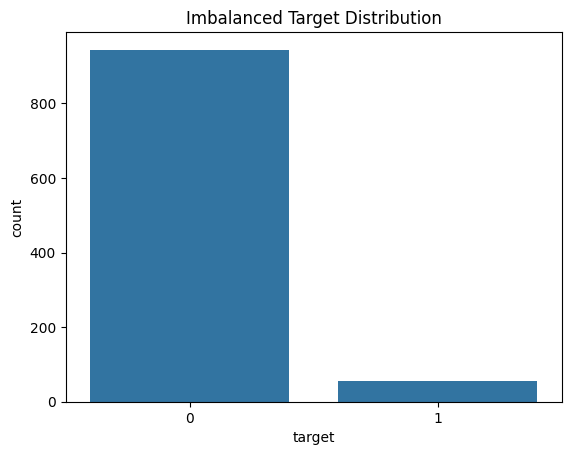

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='target', data=df)
plt.title("Imbalanced Target Distribution")
plt.show()

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

from imblearn.over_sampling import SMOTE

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (800, 10)
Test shape: (200, 10)


In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# ==========================================
# 7. Baseline Logistic Regression
# ==========================================

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

In [13]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_lr))

Confusion Matrix:
[[187   2]
 [ 11   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97       189
           1       0.00      0.00      0.00        11

    accuracy                           0.94       200
   macro avg       0.47      0.49      0.48       200
weighted avg       0.89      0.94      0.91       200

ROC-AUC Score: 0.8787878787878789


In [14]:
# ==========================================
# 9. Logistic Regression with Class Weight
# ==========================================

lr_balanced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

lr_balanced.fit(X_train_scaled, y_train)

y_pred_bal = lr_balanced.predict(X_test_scaled)
y_prob_bal = lr_balanced.predict_proba(X_test_scaled)[:, 1]

In [15]:

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_bal))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_bal))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_bal))

Confusion Matrix:
[[144  45]
 [  2   9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.76      0.86       189
           1       0.17      0.82      0.28        11

    accuracy                           0.77       200
   macro avg       0.58      0.79      0.57       200
weighted avg       0.94      0.77      0.83       200

ROC-AUC Score: 0.8720538720538721


In [18]:
# ==========================================
# 11. Apply SMOTE on Training Data Only    
# ==========================================

smote = SMOTE(random_state=42) #"Synthetic Minority Over-sampling Technique"

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:")
print(y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
[0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 

In [19]:
lr_smote = LogisticRegression(max_iter=1000)

lr_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = lr_smote.predict(X_test_scaled)
y_prob_smote = lr_smote.predict_proba(X_test_scaled)[:, 1]

In [20]:

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_smote))

Confusion Matrix:
[[144  45]
 [  2   9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.76      0.86       189
           1       0.17      0.82      0.28        11

    accuracy                           0.77       200
   macro avg       0.58      0.79      0.57       200
weighted avg       0.94      0.77      0.83       200

ROC-AUC Score: 0.8739778739778741


In [21]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [22]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))

Confusion Matrix:
[[189   0]
 [ 10   1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       189
           1       1.00      0.09      0.17        11

    accuracy                           0.95       200
   macro avg       0.97      0.55      0.57       200
weighted avg       0.95      0.95      0.93       200

ROC-AUC Score: 0.905964405964406


In [23]:
# ==========================================
# 16. Compare All Models
# ==========================================

results = pd.DataFrame({
    'Model': ['Baseline LR', 'Balanced LR', 'SMOTE LR', 'Random Forest'],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_bal),
        precision_score(y_test, y_pred_smote),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_bal),
        recall_score(y_test, y_pred_smote),
        recall_score(y_test, y_pred_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_bal),
        f1_score(y_test, y_pred_smote),
        f1_score(y_test, y_pred_rf)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_bal),
        roc_auc_score(y_test, y_prob_smote),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

print(results)

           Model  Precision    Recall  F1 Score   ROC-AUC
0    Baseline LR   0.000000  0.000000  0.000000  0.878788
1    Balanced LR   0.166667  0.818182  0.276923  0.872054
2       SMOTE LR   0.166667  0.818182  0.276923  0.873978
3  Random Forest   1.000000  0.090909  0.166667  0.905964


In [24]:
y_pred_rf_30 = (y_prob_rf > 0.30).astype(int)

print("Confusion Matrix (Threshold = 0.30):")
print(confusion_matrix(y_test, y_pred_rf_30))

print("\nClassification Report (Threshold = 0.30):")
print(classification_report(y_test, y_pred_rf_30))

Confusion Matrix (Threshold = 0.30):
[[188   1]
 [  8   3]]

Classification Report (Threshold = 0.30):
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       189
           1       0.75      0.27      0.40        11

    accuracy                           0.95       200
   macro avg       0.85      0.63      0.69       200
weighted avg       0.95      0.95      0.94       200

